In [4]:
# Instalamos yfinance para bajar datos reales del mercado
!pip install yfinance matplotlib pandas sqlalchemy

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

print("¡Todo listo para empezar el proyecto!")




¡Todo listo para empezar el proyecto!


In [5]:

# 1. Definir qué activo queremos analizar. 
# Podemos usar 'AAPL' (Apple) o 'GGAL.BA' (Galicia en el Merval)
ticket = 'AAPL' 

# 2. Bajar los datos de los últimos 2 años
datos = yf.download(ticket, start='2024-01-01')

# 3. Ver las primeras filas para confirmar que bajó bien
datos.head(20)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187729,183.799489,181.376900,182.158066,58414500
2024-01-04,179.873917,181.040702,178.855446,180.111221,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500
2024-01-09,183.067825,183.077708,180.684796,181.861479,42841800
2024-01-10,184.106049,184.313690,181.861452,182.286647,46792900
2024-01-11,183.512756,184.956422,181.564805,184.452120,49128400


In [6]:
# 1. Bajamos los datos
ticket = 'AAPL'
datos = yf.download(ticket, start='2024-01-01')

# --- EL TRUCO ESTÁ AQUÍ ---
# Si yfinance trae varias columnas por activo, las aplanamos
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)

# Reseteamos el índice para que 'Date' sea una columna real y no solo el índice
datos = datos.reset_index()
# --------------------------

# 2. Guardamos en SQLite
import sqlite3
conexion = sqlite3.connect('data/finanzas.db')

# Guardamos (usamos index=False porque ya convertimos la fecha en columna)
datos.to_sql('activos', conexion, if_exists='replace', index=False)

print("Columnas guardadas:", datos.columns.tolist())
conexion.close()

[*********************100%***********************]  1 of 1 completed

Columnas guardadas: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [7]:
conexion = sqlite3.connect('data/finanzas.db')
query = "SELECT Date, Close FROM activos WHERE Close > 190 ORDER BY Date DESC"
dias_altos = pd.read_sql(query, conexion)

print(dias_altos.head())
conexion.close()

                  Date       Close
0  2026-05-14 00:00:00  298.209991
1  2026-05-13 00:00:00  298.869995
2  2026-05-12 00:00:00  294.799988
3  2026-05-11 00:00:00  292.679993
4  2026-05-08 00:00:00  293.050018


In [8]:
### seccion de limpieza de datos
# busqueda de datos null
nulos_antes = datos.isnull().sum().sum()
print(f"valores nulos encontrados: {nulos_antes}")

valores nulos encontrados: 0


In [9]:
#si hubiera null podriamos utilizar ffill() para propagar dato anterior 
"""
datos = datos.ffill()
"""

'\ndatos = datos.ffill()\n'

In [10]:
#eliminar duplicados
duplicados = datos.duplicated().sum()
print(f"registros duplicados: {duplicados}")
datos = datos.drop_duplicates()


registros duplicados: 0


In [11]:
# verificar tipos de datos 
# aseguremos date
datos['Date'] = pd.to_datetime(datos['Date'])
datos['Date']

0     2024-01-02
1     2024-01-03
2     2024-01-04
3     2024-01-05
4     2024-01-08
         ...    
589   2026-05-08
590   2026-05-11
591   2026-05-12
592   2026-05-13
593   2026-05-14
Name: Date, Length: 594, dtype: datetime64[ns]

In [12]:
#filtrar valores inconsistentes
datos =  datos[datos['Close']>0]

print("limpieza datos completa")


limpieza datos completa


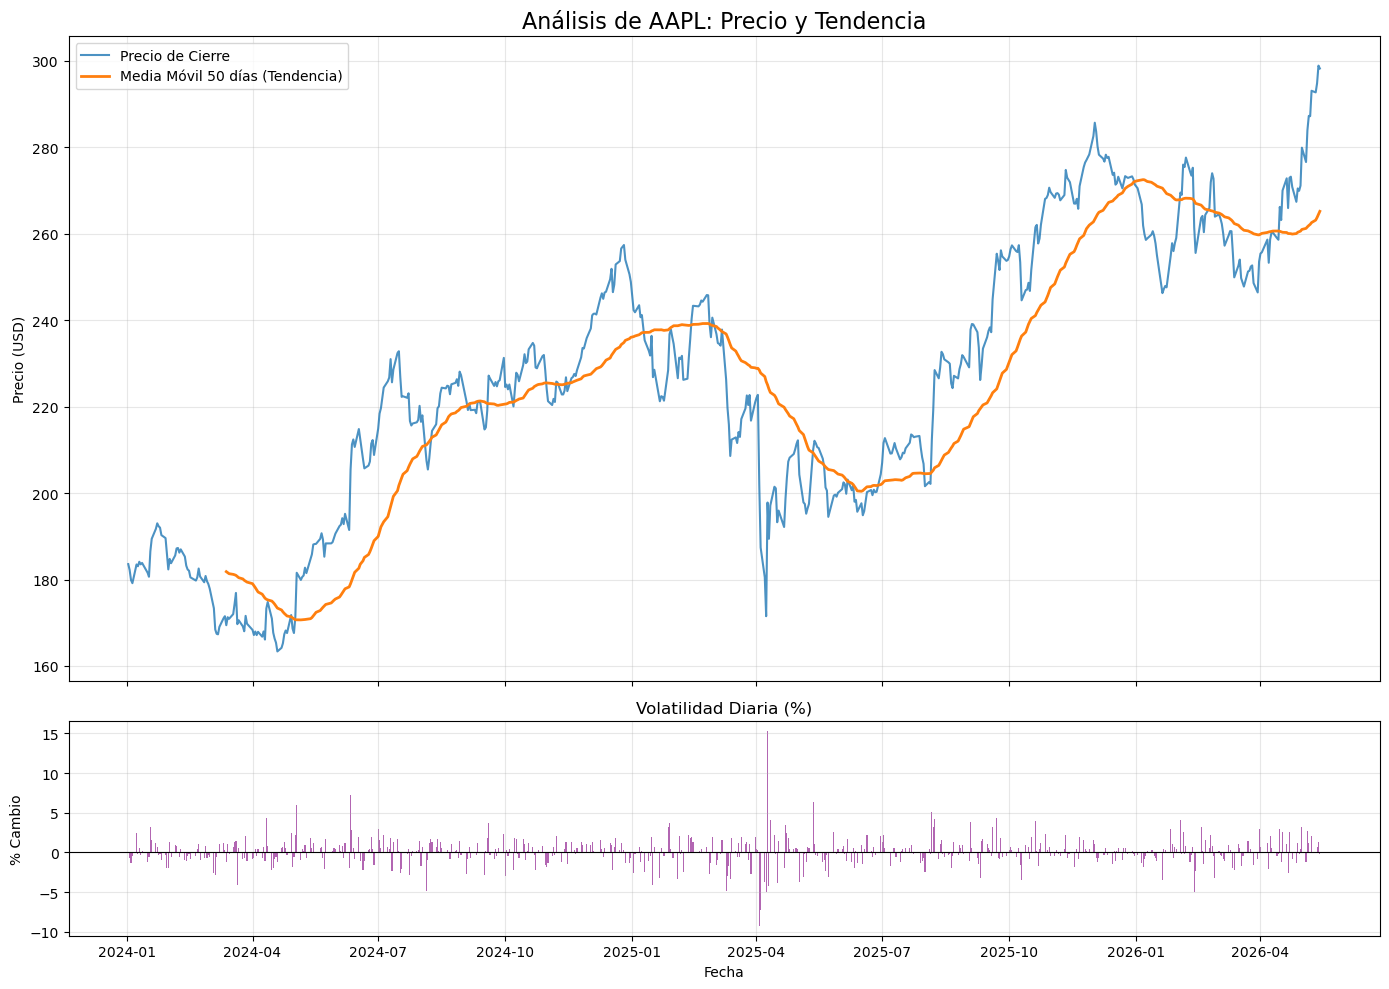

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cálculos rápidos con Pandas
# Media móvil de 50 días para ver la tendencia
datos['MA50'] = datos['Close'].rolling(window=50).mean()

# Rendimiento diario (porcentaje de cambio)
datos['Rendimiento_Diario'] = datos['Close'].pct_change() * 100

# 2. Creamos una figura con dos subgráficos (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- GRÁFICO SUPERIOR: Precios y Tendencia ---
ax1.plot(datos['Date'], datos['Close'], label='Precio de Cierre', color='#1f77b4', alpha=0.8)
ax1.plot(datos['Date'], datos['MA50'], label='Media Móvil 50 días (Tendencia)', color='#ff7f0e', linewidth=2)
ax1.set_title(f'Análisis de {ticket}: Precio y Tendencia', fontsize=16)
ax1.set_ylabel('Precio (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- GRÁFICO INFERIOR: Volatilidad (Rendimientos) ---
ax2.bar(datos['Date'], datos['Rendimiento_Diario'], color='purple', alpha=0.6)
ax2.axhline(0, color='black', linewidth=0.8) # Línea en el 0%
ax2.set_title('Volatilidad Diaria (%)', fontsize=12)
ax2.set_ylabel('% Cambio')
ax2.set_xlabel('Fecha')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()